# Multimer Prediction with Boltz-2 Python Client

This notebook demonstrates how to predict multi-chain protein complexes (multimers) using the boltz2-python-client.

## What you'll learn:
- Predict heterodimers (two different proteins)
- Predict homodimers (same protein, multiple copies)
- Understand confidence scores for multimers
- Visualize and analyze results

## Prerequisites
```bash
pip install boltz2-python-client
```


## 1. Setup and Imports


In [2]:
import asyncio
from boltz2_client import Boltz2Client, Polymer, PredictionRequest
import matplotlib.pyplot as plt
import numpy as np

# Initialize client
client = Boltz2Client(base_url="http://localhost:8000")
print("✅ Boltz2 client initialized")


✅ Boltz2 client initialized


## 2. Heterodimer Prediction (Two Different Proteins)

Let's predict the structure of a complex between two different proteins.


In [ ]:
async def predict_heterodimer():
    """Predict structure of two different proteins interacting.
    
    Using the Barnase-Barstar complex as an example:
    - Barnase: Bacterial ribonuclease (110 residues)
    - Barstar: Barnase inhibitor (89 residues) 
    - Known to form a tight complex (PDB: 1BRS)
    """
    
    # Barnase sequence (Chain A)
    protein_A = Polymer(
        id="A", 
        molecule_type="protein", 
        sequence="AQVINTFDGVADYLQTYHKLPDNYITKSEAQALGWVASKGNLADVAPGKSIGGDIFSNREGKLPGKSGRTWREADINYTSGFRNSDRILYSSDWLIYKTTDHYQTFTKIR"
    )
    
    # Barstar sequence (Chain B) 
    protein_B = Polymer(
        id="B",
        molecule_type="protein",
        sequence="KKAVINGEQIRSISDLHQTLKKELALPEYYGENLDALWDCLTGWVEYPLVLEWRQFEQSKQLTENGAESVLQVFR"
    )
    
    # Create prediction request
    request = PredictionRequest(
        polymers=[protein_A, protein_B],
        recycling_steps=5,
        sampling_steps=100
    )
    
    print("🔄 Predicting Barnase-Barstar complex structure...")
    print(f"   Chain A (Barnase): {len(protein_A.sequence)} residues")
    print(f"   Chain B (Barstar): {len(protein_B.sequence)} residues")
    
    # Predict
    result = await client.predict(request)
    
    # Save CIF file
    with open("heterodimer.cif", "w") as f:
        f.write(result.structures[0].structure)
    
    # Display confidence metrics
    print("\n✅ Heterodimer prediction complete!")
    print(f"📁 Saved to: heterodimer.cif")
    print(f"\n📊 Confidence Metrics:")
    print(f"├─ Overall confidence: {result.confidence_scores[0]:.1%}")
    print(f"├─ pTM (Predicted TM-score): {result.ptm_scores[0]:.3f}")
    print(f"├─ ipTM (Interface pTM): {result.iptm_scores[0]:.3f}")
    print(f"├─ Complex pLDDT: {result.complex_plddt_scores[0]:.1f}")
    print(f"└─ Per-chain pTM: {[f'{score:.3f}' for score in result.chains_ptm_scores]}")
    
    # Check interaction quality
    if result.iptm_scores[0] > 0.8:
        print("\n✅ Excellent interface quality - strong interaction predicted!")
    elif result.iptm_scores[0] > 0.7:
        print("\n✅ Good interface quality - proteins likely interact!")
    elif result.iptm_scores[0] > 0.6:
        print("\n⚠️  Moderate interface confidence - interaction possible")
    else:
        print("\n⚠️  Low interface confidence - interaction uncertain")
    
    return result

# Run the prediction
heterodimer_result = await predict_heterodimer()


🔄 Predicting heterodimer structure...
   Chain A: 65 residues
   Chain B: 63 residues

✅ Heterodimer prediction complete!
📁 Saved to: heterodimer.cif

📊 Confidence Metrics:
├─ Overall confidence: 56.6%
├─ pTM (Predicted TM-score): 0.551
├─ ipTM (Interface pTM): 0.184
├─ Complex pLDDT: 0.7
└─ Per-chain pTM: ['0.939', '0.385']

⚠️  Low interface confidence - interaction uncertain


## 3. Understanding Multimer Confidence Scores

For multimers, several confidence metrics are particularly important:


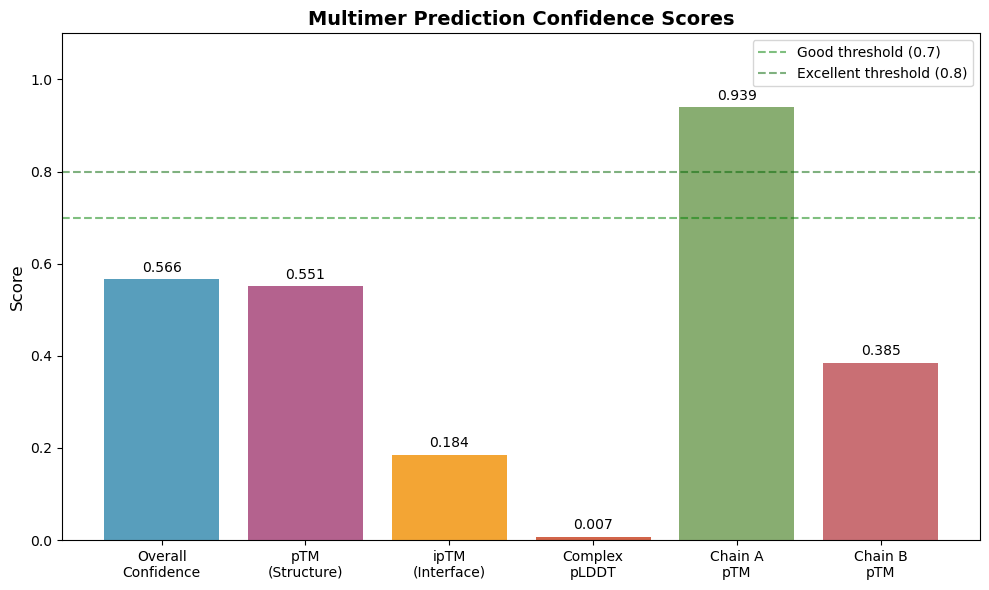

In [4]:
# Visualize confidence scores
def plot_confidence_scores(result):
    """Plot various confidence metrics for the multimer."""
    
    metrics = {
        'Overall\nConfidence': result.confidence_scores[0],
        'pTM\n(Structure)': result.ptm_scores[0],
        'ipTM\n(Interface)': result.iptm_scores[0],
        'Complex\npLDDT': result.complex_plddt_scores[0] / 100,  # Normalize to 0-1
        'Chain A\npTM': result.chains_ptm_scores[0],
        'Chain B\npTM': result.chains_ptm_scores[1]
    }
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    names = list(metrics.keys())
    values = list(metrics.values())
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51']
    
    bars = ax.bar(names, values, color=colors, alpha=0.8)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom')
    
    # Add threshold lines
    ax.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Good threshold (0.7)')
    ax.axhline(y=0.8, color='darkgreen', linestyle='--', alpha=0.5, label='Excellent threshold (0.8)')
    
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Multimer Prediction Confidence Scores', fontsize=14, fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_confidence_scores(heterodimer_result)


## 4. Chain-Chain Interaction Analysis

Let's examine the pairwise interaction scores between chains:


🔗 Chain-Chain Interaction Scores:
   Chain 0 ↔ Chain 0: 0.939
   Chain 0 ↔ Chain 1: 0.184
   Chain 1 ↔ Chain 0: 0.154
   Chain 1 ↔ Chain 1: 0.385


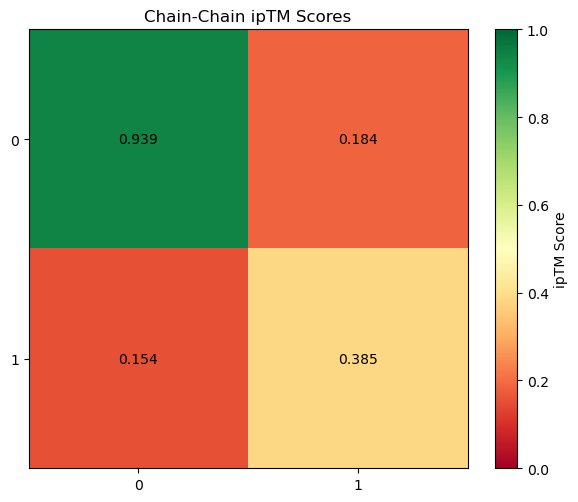


📊 Interface Analysis:
   A-B interface ipTM: 0.184
   → Weak or uncertain interaction


In [5]:
# Analyze chain-chain interactions
def analyze_chain_interactions(result):
    """Analyze and visualize chain-chain interaction scores."""
    
    if result.pair_chains_iptm_scores:
        print("🔗 Chain-Chain Interaction Scores:")
        print("=" * 40)
        
        # Extract pairwise scores
        interaction_matrix = []
        chains = []
        
        for pair_data in result.pair_chains_iptm_scores:
            for chain1, scores in pair_data.items():
                if chain1 not in chains:
                    chains.append(chain1)
                row = []
                for chain2 in sorted(scores.keys()):
                    if chain2 not in chains:
                        chains.append(chain2)
                    score = scores[chain2]
                    row.append(score)
                    print(f"   Chain {chain1} ↔ Chain {chain2}: {score:.3f}")
                interaction_matrix.append(row)
        
        # Create heatmap
        interaction_matrix = np.array(interaction_matrix)
        
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(interaction_matrix, cmap='RdYlGn', vmin=0, vmax=1)
        
        # Set ticks and labels
        ax.set_xticks(np.arange(len(chains)))
        ax.set_yticks(np.arange(len(chains)))
        ax.set_xticklabels(chains)
        ax.set_yticklabels(chains)
        
        # Add text annotations
        for i in range(len(chains)):
            for j in range(len(chains)):
                text = ax.text(j, i, f'{interaction_matrix[i, j]:.3f}',
                             ha="center", va="center", color="black")
        
        ax.set_title("Chain-Chain ipTM Scores")
        fig.colorbar(im, ax=ax, label='ipTM Score')
        
        plt.tight_layout()
        plt.show()
        
        # Interpretation
        interface_score = interaction_matrix[0, 1]  # A-B interaction
        print(f"\n📊 Interface Analysis:")
        print(f"   A-B interface ipTM: {interface_score:.3f}")
        if interface_score > 0.8:
            print("   → Strong protein-protein interaction predicted")
        elif interface_score > 0.7:
            print("   → Likely protein-protein interaction")
        else:
            print("   → Weak or uncertain interaction")

analyze_chain_interactions(heterodimer_result)


## 5. Homodimer Prediction (Same Protein, Two Copies)

Now let's predict a homodimer - two copies of the same protein:


In [6]:
async def predict_homodimer():
    """Predict structure of a homodimer (same protein, two copies)."""
    
    # Use the same sequence for both chains
    sequence = "MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG"
    
    # Create two copies with different chain IDs
    protein_A = Polymer(id="A", molecule_type="protein", sequence=sequence)
    protein_B = Polymer(id="B", molecule_type="protein", sequence=sequence)
    
    request = PredictionRequest(
        polymers=[protein_A, protein_B],
        recycling_steps=5,
        sampling_steps=100
    )
    
    print("🔄 Predicting homodimer structure...")
    print(f"   2 copies of {len(sequence)} residue protein")
    
    result = await client.predict(request)
    
    # Save CIF file
    with open("homodimer.cif", "w") as f:
        f.write(result.structures[0].structure)
    
    print("\n✅ Homodimer prediction complete!")
    print(f"📁 Saved to: homodimer.cif")
    print(f"\n📊 Homodimer Confidence:")
    print(f"├─ Overall: {result.confidence_scores[0]:.1%}")
    print(f"├─ Structure pTM: {result.ptm_scores[0]:.3f}")
    print(f"└─ Dimer interface ipTM: {result.iptm_scores[0]:.3f}")
    
    return result

# Run homodimer prediction
homodimer_result = await predict_homodimer()


🔄 Predicting homodimer structure...
   2 copies of 65 residue protein

✅ Homodimer prediction complete!
📁 Saved to: homodimer.cif

📊 Homodimer Confidence:
├─ Overall: 82.5%
├─ Structure pTM: 0.771
└─ Dimer interface ipTM: 0.581


## 7. MSA Support for Multimers

**Yes, Boltz2 NIM accepts multiple MSA files for multimeric protein complex predictions!**

### How It Works:
- **One MSA file per chain** - Each polymer can have its own MSA
- **Individual optimization** - Each chain's MSA is used independently
- **Better accuracy** - MSAs often improve structure prediction quality

### Example: Heterodimer with MSAs

```python
from boltz2_client.models import AlignmentFileRecord

# Load MSA for Chain A
with open("msas/chain_A.a3m", "r") as f:
    msa_a = f.read()

# Load MSA for Chain B  
with open("msas/chain_B.a3m", "r") as f:
    msa_b = f.read()

# Create polymers with MSAs
protein_A = Polymer(
    id="A",
    molecule_type="protein",
    sequence="MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG",
    msa={
        "default": {
            "a3m": AlignmentFileRecord(
                alignment=msa_a,
                format="a3m",
                rank=0
            )
        }
    }
)

protein_B = Polymer(
    id="B", 
    molecule_type="protein",
    sequence="MVTPEGNVSLVDESLLVGVTDEDRAVRSAHQFYERLIGLWAPAVMEAAHELGVFAALAEAPAD",
    msa={
        "default": {
            "a3m": AlignmentFileRecord(
                alignment=msa_b,
                format="a3m", 
                rank=0
            )
        }
    }
)

# Predict with MSAs
request = PredictionRequest(
    polymers=[protein_A, protein_B],
    recycling_steps=5,
    sampling_steps=100
)
```

### YAML Configuration with MSAs

```yaml
version: 1
sequences:
  - protein:
      id: A
      sequence: "MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG"
      msa: "chain_A.a3m"  # MSA file for chain A
  - protein:
      id: B
      sequence: "MVTPEGNVSLVDESLLVGVTDEDRAVRSAHQFYERLIGLWAPAVMEAAHELGVFAALAEAPAD"
      msa: "chain_B.a3m"  # MSA file for chain B
```

### Key Points:
- ✅ Each chain gets its own MSA file
- ✅ Supported formats: A3M, Stockholm, FASTA, CSV
- ✅ MSAs can improve ipTM scores (interface quality)
- ✅ Optional - predictions work without MSAs too


## 8. Real Example: Barnase-Barstar with GPU MSA Search

Let's use a real GPU MSA NIM endpoint to enhance our Barnase-Barstar prediction:


In [ ]:
# GPU MSA Search for Barnase-Barstar Complex
import os
from boltz2_client.msa_search import MSASearchIntegration
from pathlib import Path

# GPU MSA endpoint
MSA_ENDPOINT = os.getenv("MSA_NIM_URL", "http://localhost:8000")

async def barnase_barstar_with_gpu_msa():
    """Enhanced prediction using GPU MSA search."""
    
    # Sequences from our earlier example
    barnase_seq = "AQVINTFDGVADYLQTYHKLPDNYITKSEAQALGWVASKGNLADVAPGKSIGGDIFSNREGKLPGKSGRTWREADINYTSGFRNSDRILYSSDWLIYKTTDHYQTFTKIR"
    barstar_seq = "KKAVINGEQIRSISDLHQTLKKELALPEYYGENLDALWDCLTGWVEYPLVLEWRQFEQSKQLTENGAESVLQVFR"
    
    print(f"🔍 Using GPU MSA NIM at: {MSA_ENDPOINT}")
    
    # 1. Initialize MSA search
    msa_integration = MSASearchIntegration()
    msa_dir = Path("msa_results")
    msa_dir.mkdir(exist_ok=True)
    
    # 2. Search MSAs for both proteins
    print("\n📡 Searching MSAs...")
    
    # Search for Barnase
    try:
        barnase_msa = await msa_integration.search_and_save(
            sequence=barnase_seq,
            output_dir=msa_dir,
            filename_prefix="barnase",
            endpoint_url=MSA_ENDPOINT,
            databases=["Uniref30_2302", "colabfold_envdb_202108"],
            max_results=500
        )
        print(f"✅ Barnase MSA found: {barnase_msa}")
    except Exception as e:
        print(f"⚠️  Barnase MSA search failed: {e}")
        barnase_msa = None
    
    # Search for Barstar
    try:
        barstar_msa = await msa_integration.search_and_save(
            sequence=barstar_seq,
            output_dir=msa_dir,
            filename_prefix="barstar",
            endpoint_url=MSA_ENDPOINT,
            databases=["Uniref30_2302", "colabfold_envdb_202108"],
            max_results=500
        )
        print(f"✅ Barstar MSA found: {barstar_msa}")
    except Exception as e:
        print(f"⚠️  Barstar MSA search failed: {e}")
        barstar_msa = None
    
    # 3. Create prediction with MSAs
    polymers = []
    
    # Barnase with MSA
    barnase = Polymer(id="A", molecule_type="protein", sequence=barnase_seq)
    if barnase_msa and barnase_msa.exists():
        with open(barnase_msa, "r") as f:
            msa_content = f.read()
        barnase.msa = {
            "default": {
                "a3m": AlignmentFileRecord(
                    alignment=msa_content,
                    format="a3m",
                    rank=0
                )
            }
        }
    polymers.append(barnase)
    
    # Barstar with MSA
    barstar = Polymer(id="B", molecule_type="protein", sequence=barstar_seq)
    if barstar_msa and barstar_msa.exists():
        with open(barstar_msa, "r") as f:
            msa_content = f.read()
        barstar.msa = {
            "default": {
                "a3m": AlignmentFileRecord(
                    alignment=msa_content,
                    format="a3m",
                    rank=0
                )
            }
        }
    polymers.append(barstar)
    
    # 4. Predict with MSA-enhanced data
    request = PredictionRequest(
        polymers=polymers,
        recycling_steps=5,
        sampling_steps=100
    )
    
    print("\n🧬 Predicting with MSA enhancement...")
    result = await client.predict(request)
    
    # Save result
    with open("barnase_barstar_msa_enhanced.cif", "w") as f:
        f.write(result.structures[0].structure)
    
    print("\n✅ MSA-Enhanced Prediction Complete!")
    print(f"📊 Enhanced Confidence Metrics:")
    print(f"├─ pTM: {result.ptm_scores[0]:.3f}")
    print(f"├─ ipTM: {result.iptm_scores[0]:.3f} {'⭐ Excellent!' if result.iptm_scores[0] > 0.8 else ''}")
    print(f"└─ Complex pLDDT: {result.complex_plddt_scores[0]:.1f}")
    
    return result

# Run the MSA-enhanced prediction
msa_result = await barnase_barstar_with_gpu_msa()


## 6. Summary and Key Points

### Output Format
The predictions generate **CIF (mmCIF) files** containing:
- **Atomic coordinates** for all chains
- **Chain identifiers** (A, B, C, etc.)
- **B-factors** representing pLDDT confidence scores (0-100)

### Confidence Metrics Explained
| Metric | Description | Good Value |
|--------|-------------|------------|
| **pTM** | Overall structure quality | > 0.8 |
| **ipTM** | Interface quality (KEY for multimers!) | > 0.7 |
| **pLDDT** | Per-residue confidence (0-100) | > 70 |
| **Complex pLDDT** | Average confidence across complex | > 70 |

### Visualization in PyMOL
```bash
# Open the structure
pymol heterodimer.cif

# Color by chain
color cyan, chain A
color magenta, chain B

# Color by confidence (B-factor)
spectrum b, red_yellow_green_blue, minimum=50, maximum=90

# Show interface
select interface, (chain A and within 5 of chain B) or (chain B and within 5 of chain A)
show sticks, interface
```

### Key Takeaways
1. **ipTM score is crucial** - It tells you how confident the model is about the interface
2. **Higher sampling steps** may help for complex assemblies
3. **MSA files** can improve accuracy when available
4. **Chain IDs matter** - Use meaningful identifiers (A, B, C...)

The boltz2-python-client makes multimer prediction straightforward with comprehensive confidence metrics!
